# Exercício de tratamento dos dados desbalanceado

conda Udemy

importações das bibliotecas

In [1]:

import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

base de dados de cobertura vegetal

## Tratamento de dados desbalanceados

## Base de dados cobertura vegetal

Neste exercício você vai mais uma vez utilizar a base de dados cobertura vegetal.


Carregue o arquivo csv salvo na pasta do Drive. Visualize o DataFrame resultante.

busca no comando linux:

find -name "cov_types.csv"

./UDEMY_ML/Machine_Learning_Udemy/10-Redes_neurais_artificiais/exercicios/novo/cov_types.csv


In [2]:
DRIVE_DIRECTORY = "../10-Redes_neurais_artificiais/exercicios/novo/"

In [4]:
import os
base = pd.read_csv(os.path.join(DRIVE_DIRECTORY, 'cov_types.csv'))

In [5]:
base.tail()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type,Cover_Type
9995,2917.0,90.0,9.0,247.0,25.0,4095.0,235.0,225.0,121.0,3901.0,0,28,Lodgepole Pine
9996,3015.0,38.0,8.0,361.0,74.0,4846.0,220.0,223.0,138.0,1611.0,0,28,Lodgepole Pine
9997,3052.0,79.0,19.0,90.0,11.0,1003.0,241.0,203.0,85.0,1490.0,2,22,Spruce/Fir
9998,2958.0,58.0,6.0,319.0,19.0,2468.0,225.0,227.0,137.0,2280.0,0,28,Lodgepole Pine
9999,2682.0,91.0,13.0,162.0,32.0,1369.0,240.0,219.0,108.0,1661.0,2,10,Lodgepole Pine


Visualizar a quantidade de elementos em cada coluna

As classes estão na coluna `Cover_Type`. Recupere esta coluna e exiba a contagem das classes. Neste caso, você pode utilizar o método `value_counts`.

In [7]:
base["Cover_Type"].value_counts() #dados desbalanceados

Cover_Type
Lodgepole Pine       4847
Spruce/Fir           3714
Ponderosa Pine        581
Krummholz             362
Douglas-fir           278
Aspen                 163
Cottonwood/Willow      55
Name: count, dtype: int64

problemas para o algoritmo de classificação 

## Visualize a contagem com auxílio da biblioteca Seaborn.

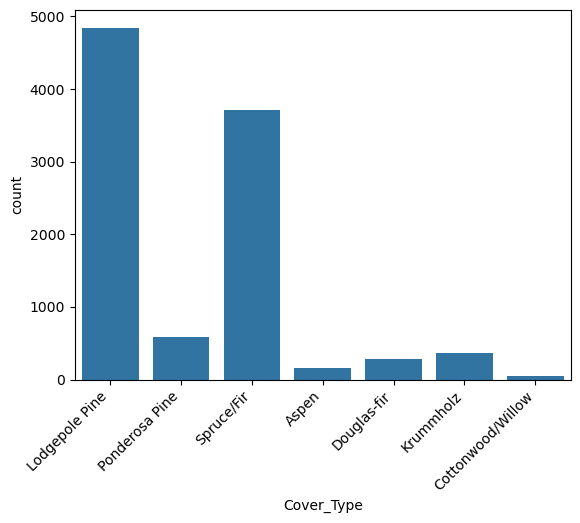

In [8]:
sns.countplot(x=base["Cover_Type"])
plt.xticks(rotation=45, ha='right');

Agora você pode carregar os mesmos dados, depois de todo o pré-processamento feito na Parte 1. Lembre-se de que eles estão armazenados no arquivo `cover_type.pkl` na pasta do Drive.

In [16]:
base.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area', 'Soil_Type',
       'Cover_Type'],
      dtype='object')

In [17]:
len(base.columns)

13

In [11]:
DRIVE_DIRECTORY_0 = "exercicio/"

In [13]:
# pré -processamento já pronto
with open(os.path.join(DRIVE_DIRECTORY_0, "cover_type.pkl"), "rb") as f:
    (X_train, y_train, X_test, y_test) = pickle.load(f)

In [15]:
X_train.shape, y_train.shape

((7500, 53), (7500,))

### Subamostragem com Tomek Links

Crie uma instância do algoritmo de subamostragem, passando parâmetro `sampling_strategy="all"`. Desta vez, nós vamos fazer a subamostragem somente nos dados de treinamento, mantendo os dados de teste intactos.

### deixaremos as classes parecidas dos elementos, apaga os dados das variáveis com os maiores números, perdendo assim valores importantes. 

#### faremos isso só na base de treinamento

In [18]:
tl = TomekLinks(sampling_strategy="all")
X_under, y_under = tl.fit_resample(X_train, y_train)

#### aplicado para todas as classes

Utilize `np.unique` para contar as classes em `y_train` (dados originais) e `y_under` (dados subamostrados).

In [20]:
np.unique(y_train, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6]),
 array([ 129,   39,  211,  275, 3617,  425, 2804]))

In [21]:
np.unique(y_under, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6]),
 array([  96,   33,  165,  253, 3333,  378, 2552]))

Agora instancie e treine um algoritmo do tipo RandomForestClassifier, utilizando os dados subamostrados.

In [22]:
tree_classifier = RandomForestClassifier(random_state=0)
tree_classifier.fit(X_under, y_under)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
tree_classifier.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 0,
 'verbose': 0,
 'warm_start': False}

Faça predições utilizando os dados de teste, e exiba a acurácia alcançada.

In [24]:
# previsão
y_pred = tree_classifier.predict(X_test)

In [25]:
y_pred[:50]

array([4, 4, 1, 4, 4, 6, 4, 6, 4, 4, 4, 0, 6, 4, 4, 6, 6, 5, 4, 4, 4, 4,
       4, 4, 6, 6, 4, 4, 4, 6, 6, 4, 6, 6, 6, 4, 5, 4, 4, 4, 4, 4, 6, 4,
       4, 4, 4, 4, 4, 6])

In [26]:
print(f'Acurácia {accuracy_score(y_test, y_pred)*100} %')

Acurácia 79.64 %


Agora exiba o reporte de classificação.

In [31]:
# valor caiu em comparação com os demais,

# ou parecido com o script abaixo

# Machine_Learning_AZ/8-Redes_neurais_artificiais/novo_exercicios/ (no github)


In [30]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.15      0.25        34
           1       0.91      0.62      0.74        16
           2       0.67      0.39      0.49        67
           3       0.93      0.63      0.75        87
           4       0.81      0.85      0.83      1230
           5       0.72      0.85      0.78       156
           6       0.78      0.78      0.78       910

    accuracy                           0.80      2500
   macro avg       0.81      0.61      0.66      2500
weighted avg       0.80      0.80      0.79      2500



Comparando com a **Parte 1.3**, nós evidenciamos que a técnica melhorou algumas métricas de algumas classes, mas piorou outras.

A Subamostragem não foi tão vantajosa; pois o acurácia não aumento significativamente;

### Sobreamostragem, a ideia é aumentarmos a quantidade de dados, criando registros sintéticos para as classes que têm poucos registros. 

## Criando registros sintéticos onde há classes com valores menores;

## Sobreamostragem com SMOTE

Agora, instancie e realize a sobreamostragem com SMOTE. Neste caso, como temos mais de uma classe, utilize sampling_strategy="auto", que equivale a sobreamostrar todas as classes menos a majoritária.

In [32]:
smote = SMOTE(sampling_strategy="auto")
X_over, y_over = smote.fit_resample(X_train, y_train)

Observe a contagem das classes nos dados originais e nos dados sobreamostrados.

In [33]:
np.unique(y_train, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6]),
 array([ 129,   39,  211,  275, 3617,  425, 2804]))

####  distribuição perfeita

In [37]:
np.unique(y_over, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6]),
 array([3617, 3617, 3617, 3617, 3617, 3617, 3617]))

Retreine o `RandomForestClassifier` com os dados sobreamostrados.

In [35]:
tree_classifier = RandomForestClassifier(random_state=0)
tree_classifier.fit(X_over, y_over)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
tree_classifier.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 0,
 'verbose': 0,
 'warm_start': False}

## Faça predições e calcule a acurácia do modelo.

In [38]:
y_pred = tree_classifier.predict(X_test) # gerando a previsão

In [39]:
y_pred[:20]

array([4, 4, 5, 4, 4, 6, 4, 6, 4, 4, 4, 0, 6, 4, 4, 6, 6, 5, 4, 4])

In [40]:
print(f'acurácia {accuracy_score(y_test, y_pred)*100} %') # acurácia

acurácia 81.0 %


Agora, em comparação com a Parte 1.3, a acurácia ficou praticamente igual.

Exiba o reporte de classificação.

In [41]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.54      0.56      0.55        34
           1       0.67      0.75      0.71        16
           2       0.60      0.54      0.57        67
           3       0.81      0.79      0.80        87
           4       0.85      0.83      0.84      1230
           5       0.72      0.85      0.78       156
           6       0.80      0.81      0.80       910

    accuracy                           0.81      2500
   macro avg       0.71      0.73      0.72      2500
weighted avg       0.81      0.81      0.81      2500



Desta vez, a precisão de algumas classes diminuiu, enquanto que o recall aumentou, sobretudo para as classes minoritárias.